In [1]:
# Importazione librerie
from libreria_trincee import Pendio,AbachiEfficienza,AbachiTemporali,AbacoPortate
import numpy as np

# Uso delle funzioni della libreria `libreria_trincee`

Questo notebook mostra esempi pratici di utilizzo delle funzioni implementate nella libreria `libreria_trincee.py`, progettata per supportare il dimensionamento di trincee drenanti e l’analisi del coefficiente di sicurezza dei pendii in condizioni idrogeotecniche semplificate.

Le funzionalità principali della libreria comprendono:

- Valutazione del coefficiente di sicurezza $F(Z)$ in presenza di falda;
- Interpolazione dell’efficienza idraulica a partire da abachi numerici;
- Analisi della portata drenata;
- Esportazione di grafici interattivi in HTML, integrabili in relazioni tecniche.

Per ciascuna funzione viene fornito un esempio chiaro, con spiegazione dei parametri in input e dell’interpretazione dei risultati.

> Un' esempio di progetto è disponibile nel notebook *esempio_progetto.ipynb*.

## Analisi del coefficiente di sicurezza $F(Z)$

La classe `Pendio` consente di valutare il coefficiente di sicurezza di un pendio indefinito, in funzione della profondità della falda, tenendo conto dell’inclinazione del versante e dei parametri geotecnici del terreno.

Questa classe permette di calcolare $F(Z)$ per più combinazioni dei seguenti parametri:

- **Coesione efficace** $c'$ [kPa]
- **Angolo di attrito efficace** $\varphi'$ [°]
- **Profondità della falda** $d_w$ [m]

### Parametri del costruttore

- `Z`: array delle profondità a cui si valuta la stabilità [m]
- `beta_deg`: inclinazione del pendio [°]
- `gamma`: peso specifico del terreno [kN/m³]
- `gamma_w`: peso specifico dell’acqua [kN/m³]
- `D`: profondità del piano di scorrimento (opzionale) [m]

I valori di $c'$, $\varphi'$ e $d_w$ sono forniti al momento del calcolo tramite il metodo `calcola_F()`.
alcola### Visualizzazione

Due metodi grafici permettono di esplorare i risultati:

- `plot_F_vs_Z_dw()`: mostra l’effetto della variazione della falda ($dw$), mantenendo fissi $c'$ e $\varphi'$;
- `plot_F_vs_Z_c_phi()`: mostra l’effetto dei parametri geotecnici ($c'$, $\varphi'$), mantenendo fisso il livello di falda $d_w$.

---

### Esempio: inizializzazione di un pendio

In questo esempio si definisce un pendio con le seguenti caratteristiche geometriche e fisiche:

- profondità $Z$ da 0.5 m a 7.5 m (20 valori equispaziati);
- inclinazione del versante: 14°;
- peso specifico del terreno: 19 kN/m³;
- peso specifico dell’acqua: 9.81 kN/m³.

I parametri geotecnici ($c'$, $\varphi'$) e la profondità della falda $dw$ vengono specificati successivamente per eseguire il calcolo del coefficiente di sicurezza.

La classe `Pendio` restituisce i risultati in forma strutturata e può produrre grafici interattivi per analizzare il comportamento del pendio.
nterattivi.endio da analizzare:

In [2]:
# Profondità da 0.5 a 7.5 m
Z = np.linspace(0.5, 7.5, 20)

# Definizione del Pendio 
pendio = Pendio(
    Z=Z,
    beta_deg=14,
    gamma=19,
    gamma_w=9.81,
    D=2.5
)

---

### 📈 Effetto del livello della falda sul coefficiente di sicurezza

Il metodo `plot_F_vs_Z_dw()` consente di valutare come il coefficiente di sicurezza $F(Z)$ cambi al variare della profondità della falda $dw$, mantenendo costanti i parametri di resistenza del terreno.

Ogni curva rappresenta uno scenario con diversa profondità della falda.

In questo esempio, il calcolo è effettuato per:

- $c' = 5$ kPa  
- $\varphi' = 28^{\circ}$  
- $d_w \in \{ 0,\, 1,\, 2,\, 3,\, 4,\, 5 \}$ m

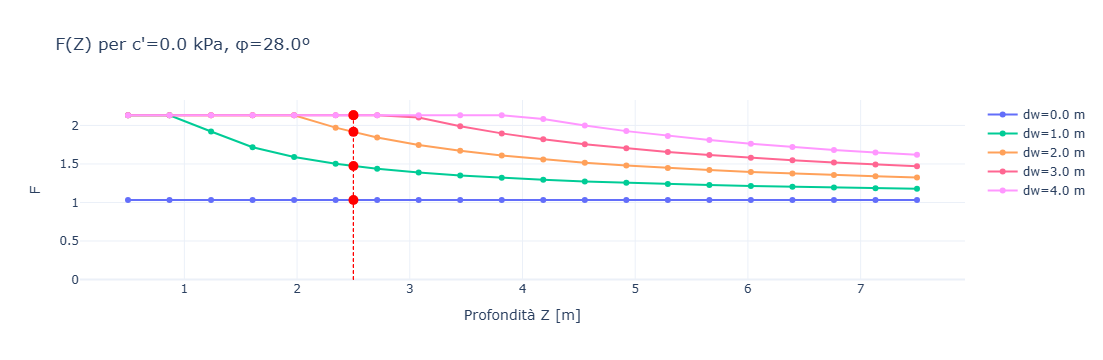

In [3]:
# Parametri fissi per questo plot
c_list = [0.0]
phi_list = [28.0]
dw_list = [0.0,1.0, 2.0, 3.0, 4.0]

# Calcolo
F_dict = pendio.calcola_F(c_list, phi_list, dw_list,)

# Plot al variare di dw
pendio.plot_F_vs_Z_dw(F_dict, c=0.0, phi=28.0)

### 📉 Influenza dei parametri geotecnici $ c' $ e $ \phi' $ sul coefficiente di sicurezza

Il metodo `plot_F_vs_Z_c_phi()` consente di analizzare la sensibilità del coefficiente di sicurezza $ F(Z)$ rispetto ai parametri di resistenza del terreno.  
Viene tracciata una curva per ogni combinazione tra coesione efficace $ c'$ e angolo d’attrito efficace $ \varphi' $, mantenendo costante la profondità della falda.

Nell’esempio seguente si confrontano:

- coesione efficace $ c' = 0,\, 5,\, 10 \,\text{kPa} $;  
- angolo d’attrito efficace $ \varphi' = 24^\circ,\, 28^\circ,\, 32^\circ $;  
- profondità della falda fissata a $ dw = 3.0 \, \text{m} $.

> 🔄 **Nota**: Il pendio è già stato definito nella sezione precedente.  
> Ora si forniscono nuovi valori di $ c' $, $ \varphi'$  e $ d_w $ per eseguire il calcolo.

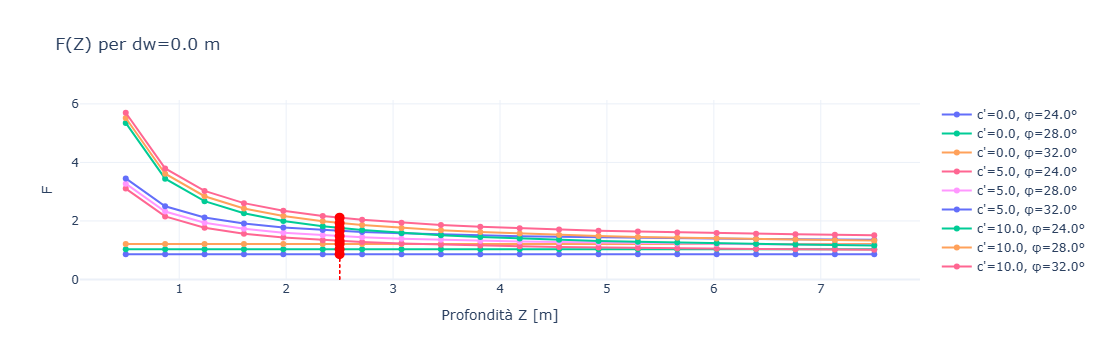

In [4]:
# Parametri geotecnici da confrontare
c_list = [0.0, 5.0, 10.0]
phi_list = [24.0, 28.0, 32.0]
dw_list = [0.0]  # falda fissa

# Calcolo del coefficiente di sicurezza per tutte le combinazioni
F_dict = pendio.calcola_F(c_list, phi_list, dw_list)

# Visualizzazione al variare di c' e φ', con falda a 3.0 m
pendio.plot_F_vs_Z_c_phi(F_dict, dw=0.0)

---
## Abachi per l'efficienza idraulica media delle trincee drenanti

Gli **abachi** sono grafici che forniscono i valori dell'efficienza idraulica media in funzione di diversi parametri geometrici adimensionalizzati. Questi abachi sono stati ottenuti da simulazioni numeriche condotte in condizioni controllate, come descritto nel lavoro di **Desideri A., Miliziano S., Rampello S. (1997)**, intitolato *Drenaggi a gravità per la stabilizzazione dei pendii*, pubblicato in **Argomenti di Ingegneria Geotecnica, Hevelius Edizioni, Benevento**. [Link al documento PDF](https://www.ordineingegnerilecce.it/wp-content/uploads/2021/06/DRENAGGIweb-1.pdf).

Gli abachi sono costruiti utilizzando i seguenti parametri adimensionali:

- $S/H_0$: rapporto tra l'interasse delle trincee e la profondità della trincea.
- $d=D/H_0$: rapporto tra la profondità del piano di valutazione dell'efficienza e la profondità della trincea.
- $n=H/H_0$: rapporto tra la profondità del substrato impermeabile ($H$) e la profondità della trincea ($H_0$), con valori che possono essere 1, 1.5, 2.5, 4.0.

I dati forniti si riferiscono a $E_{\text{med}}$ per $t \to \infty$ , cioè all'efficienza idraulica a regime, quando il sistema di drenaggio ha raggiunto il suo stato di equilibrio.

### Visualizzazione completa degli abachi

Il metodo `plot_abachi()` della classe `AbachiEfficienza` genera una visualizzazione unica che raccoglie i quattro abachi relativi ai valori di:

- $n = 1.0$
- $n = 1.5$
- $n = 2.5$
- $n = 4.0$

Ciascun pannello mostra le curve dell’efficienza idraulica media $E_{\text{med}}$ al variare del parametro $S/H_0$, per diversi valori di $D/H_0$ (profondità del piano di valutazione).  
La visualizzazione consente un confronto immediato tra i diversi scenari di progetto.


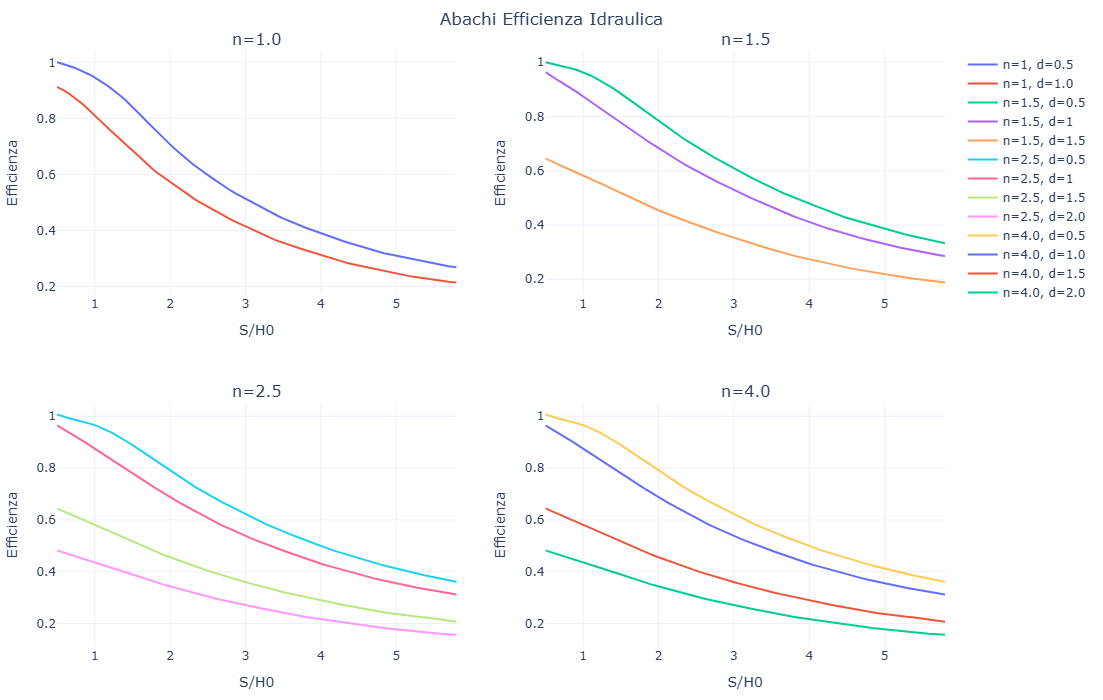

In [5]:
# Crea un'istanza della classe Abachi
abachiE = AbachiEfficienza()

# Traccia i grafici degli abachi
abachiE.plot_abachi()

---
## Abachi temporali dell’efficienza idraulica

Oltre all’efficienza idraulica media a regime, è possibile analizzare il comportamento del sistema di drenaggio in condizioni transitorie, valutando il tempo necessario a raggiungere una determinata percentuale dell’efficienza finale.

La classe `AbachiTemporali` fornisce due tipi di abachi:

- $T_{50}$: tempo adimensionale in cui l’efficienza raggiunge il 50% del valore finale;
- $T_{90}$: tempo adimensionale in cui l’efficienza raggiunge il 90% del valore finale.

### Visualizzazione completa degli abachi

Il metodo `plot_abachi()` della classe `AbachiTemporali` genera una figura composta da quattro pannelli:

- due pannelli per i valori di $n = 1.0$ e $n = 2.5$;
- ciascun pannello contiene le curve per i valori di $ D/H_0 = \{0.5, 1.0, 1.5, 2.0\} $;
- sia per il tempo $T_{50}$ che per $T_{90}$.

In [6]:
abachiT = AbachiTemporali()
abachiT.plot_abachi()

---
## Abaco per il fattore di portata drenata
La classe `AbacoPortate` consente di stimare la **portata drenata per unità di lunghezza** da una trincea, utilizzando un **fattore di portata adimensionale** $ q $, ricavato da documentazione tecnica disponibile in letteratura.

Il coefficiente $ q $ è definito come:

$$
q = \frac{Q}{D \cdot k_h} \sqrt{\frac{k_v}{k_h}}
$$

da cui si ricava:

$$
Q = q \cdot D \cdot k_h \cdot \sqrt{\frac{k_h}{k_v}}
$$

dove:
- $ Q $: portata drenata reale per unità di lunghezza [m²/s];
- $ D $: profondità della trincea;
- $ k_h, k_v $: permeabilità orizzontale e verticale del terreno;
- $ q $: valore adimensionale ottenuto dall’abaco;
- $ s = S^*/(2 \cdot D)$: parametro geometrico adimensionale, funzione della geometria del sistema.

L’abaco utilizzato è tratto da:

> **Ordine dei Geologi della Sardegna (s.d.)**  
> *La progettazione delle trincee drenanti per la stabilizzazione dei pendii*, Miscellanea Sarda.  
> [Link al documento PDF](https://www.geologi.sardegna.it/fileadmin/ORGS/Miscellanea_Sarda/La_progettazione_delle_trincee_drenanti_per_la_stabilizzazione_dei_pendii.pdf)

Il metodo `plot()` della classe `AbacoPortate` consente di visualizzare il grafico del fattore di portata $q(s)$, dove $s = \frac{S^*}{2D}$. È inoltre possibile esportare il grafico in formato HTML passando `export_html=True` e specificando il nome del file con l'argomento `filename`.

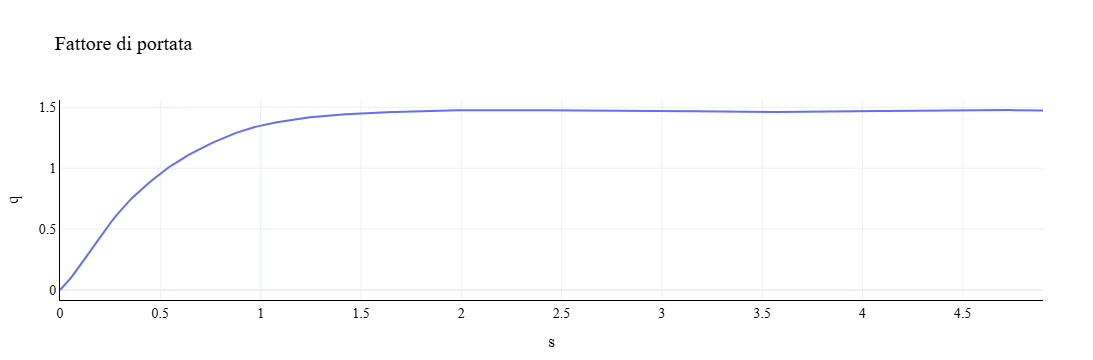

In [7]:
abacoQ = AbacoPortate()
abacoQ.plot(export_html=True, filename="Art1_AbacoPortate.html")

## Esportazione dei grafici singoli in HTML

Per ciascun abaco — sia relativo all’efficienza idraulica media che ai tempi caratteristici $T_{50}$ e $T_{90} — è possibile esportare singolarmente il grafico corrispondente in formato HTML interattivo, utilizzabile in relazioni tecniche o integrabile in un sito web.

### Efficienza idraulica media

Nel blocco seguente viene esportato un file HTML per ciascun valore di $ n = H / H_0 $, ovvero:

- $ n = 1.0 $
- $ n = 1.5 $
- $ n = 2.5 $
- $ n = 4.0 $

Ogni grafico mostra le curve di $ E_{\text{med}} $ al variare del rapporto $ S/H_0 $, per diversi valori di $ D/H_0 $.

Il metodo `plot_singolo(n, export_html=True, filename=...)` gestisce l’esportazione.

### Efficienza idraulica in regime transitorio

Anche per gli abachi relativi ai tempi adimensionali $ T_{50} $ e $ T_{90} $, è possibile esportare grafici singoli per ogni valore di $ n $.  
Il metodo `plot_singolo(tipo, n_label, filename=...)` della classe `AbachiTemporali` accetta:

- `tipo`: `"T50"` o `"T90"`;
- `n_label`: `"n1"`, `"n2p5"`, ecc.;
- `filename`: nome del file di esportazione HTML.

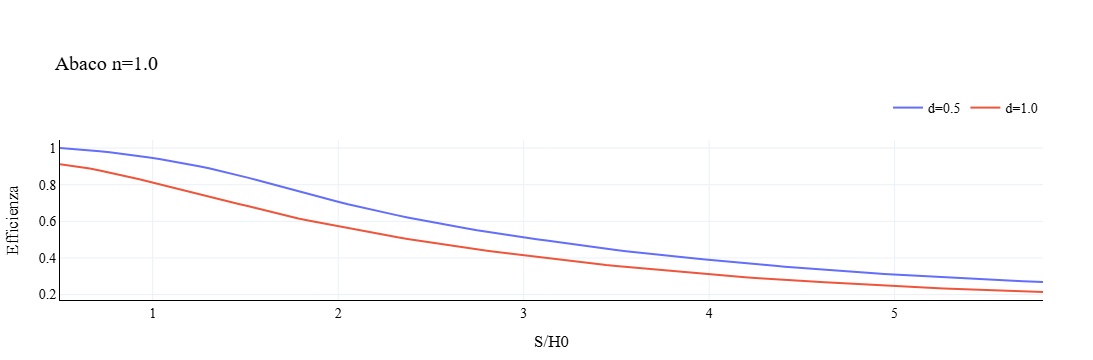

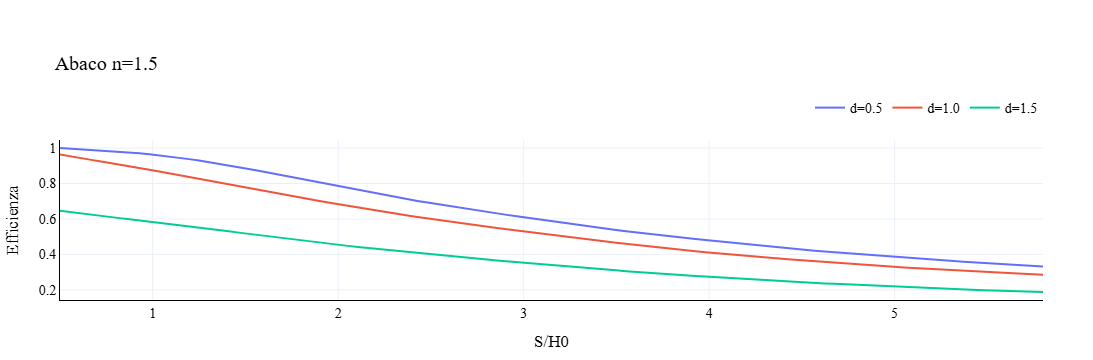

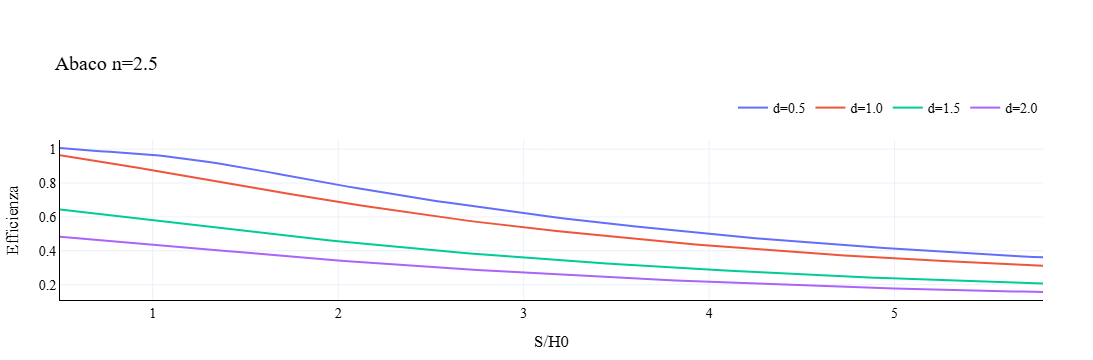

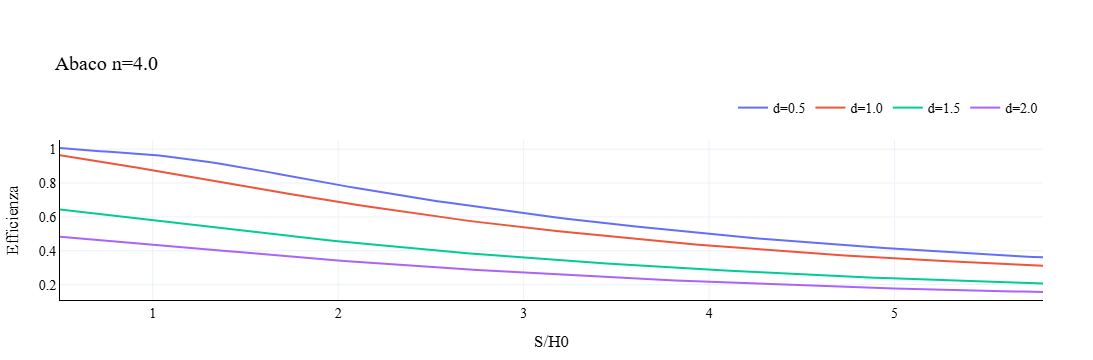

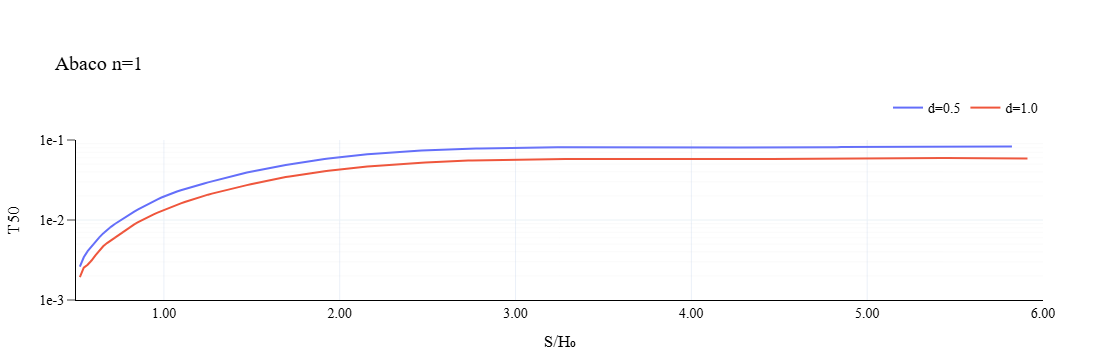

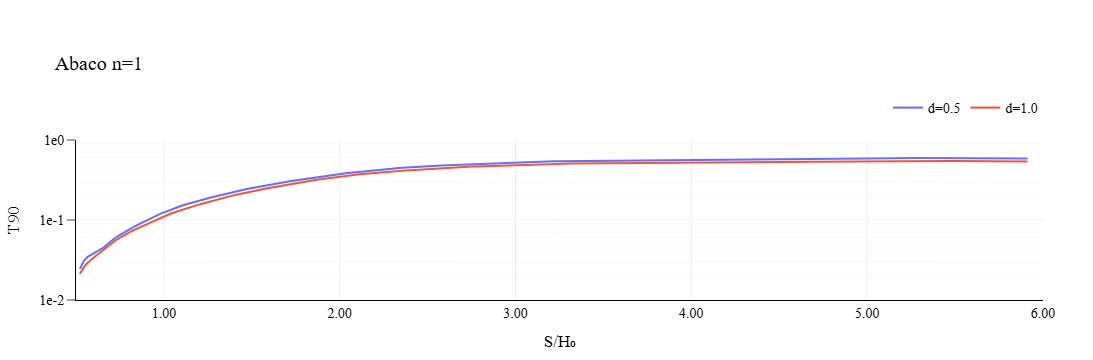

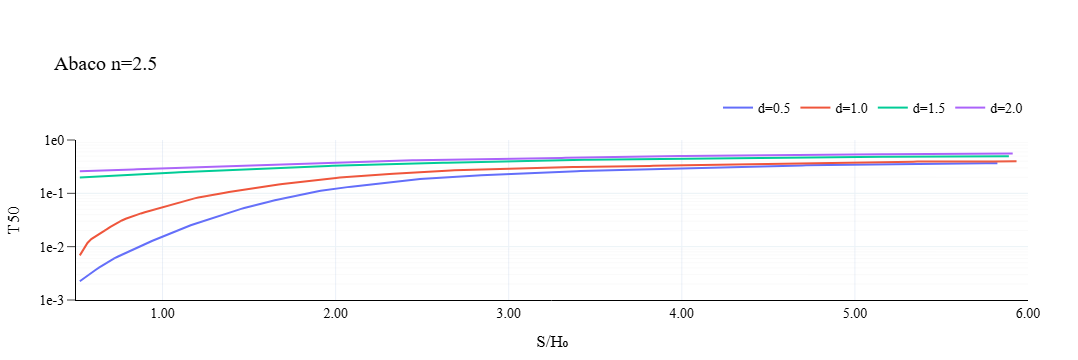

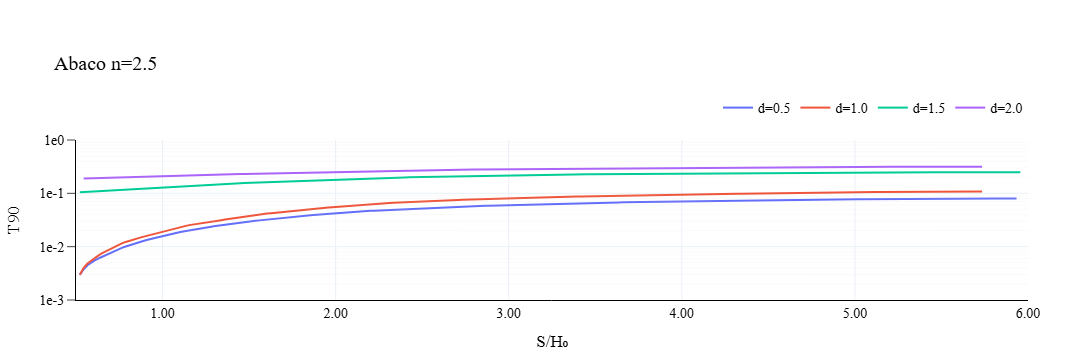

In [8]:
# === GRAFICI DI EFFICIENZA ===
efficienza_grafici = {
    "n=1.0": "Art1_Abachi_Evss-n1p0.html",
    "n=1.5": "Art1_Abachi_Evss-n1p5.html",
    "n=2.5": "Art1_Abachi_Evss-n2p5.html",
    "n=4.0": "Art1_Abachi_Evss-n4p0.html"
}

for n_value, filename in efficienza_grafici.items():
    abachiE.plot_singolo(n_value, export_html=True, filename=filename)

# === GRAFICI TEMPORALI ===
temporali_grafici = [
    ("T50", "n1", "Art1_Abachi_tempi_n1_T50.html"),
    ("T90", "n1", "Art1_Abachi_tempi_n1_T90.html"),
    ("T50", "n2p5", "Art1_Abachi_tempi_n2p5_T50.html"),
    ("T90", "n2p5", "Art1_Abachi_tempi_n2p5_T90.html")
]

for tipo, n_label, filename in temporali_grafici:
    abachiT.plot_singolo(tipo, n_label, export_html=True, filename=filename)